# FPL Predictor

In this notebook is a model that predicts the points scored by a player in the next FPL gameweek.

### Import Necessary Libraries and Data

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

In [36]:
data = pd.read_csv('fpl-data-stats.csv')
# source: www.fpl-data.co.uk/statistics
gw_positions = pd.read_csv('pl-25-26-tables.csv')
# source: www.premierleague.com

### Data Preparation

Aligning formatting and merging data into a single dataframe, renaming columns, renaming positions, sorting data.

In [37]:
data = data.drop(columns=['expected_points', 'PvsxP'])

data = data.replace({
    'Arsenal': 'arsenal',
    'Aston Villa': 'villa',
    'Bournemouth': 'bournemouth',
    'Brentford': 'brentford',
    'Brighton': 'brighton',
    'Man City': 'man city',
    'Burnley': 'burnley',
    'Chelsea': 'chelsea',
    'Crystal Palace': 'palace',
    'Everton': 'everton',
    'Fulham': 'fulham', 
    'Leeds': 'leeds',
    'Liverpool': 'liverpool',
    "Nott'm Forest": 'forest',
    'Man Utd': 'man utd',
    'Newcastle': 'newcastle',
    'Sunderland': 'sunderland',
    'Spurs': 'spurs',
    'West Ham': 'west ham',
    'Wolves': 'wolves'
})

data = data.merge(
    gw_positions[['matchweek', 'team', 'position', 'points']],
    left_on = ['gameweek', 'team_name'],
    right_on = ['matchweek', 'team'],
    how = 'left'
)
data = data.rename(
    columns = {
        'position': 'team_position',
        'points': 'team_points'
})
data = data.drop(columns=['matchweek', 'team'])
data = data.merge(
    gw_positions[['matchweek', 'team', 'position', 'points']],
    left_on = ['gameweek', 'opponent_team_name'],
    right_on = ['matchweek', 'team'],
    how = 'left'
)
data = data.rename(
    columns = {
        'position': 'opponent_position',
        'points': 'opponent_points'
})
data = data.drop(columns=['matchweek', 'team'])

data = data.rename(
    columns = {
        'id': 'player_id', 
        'element_type': 'position',
        'web_name': 'player_name',
        'was_home': 'home',
        'now_cost': 'price',
        'total_points': 'gw_points'
})
data = data.sort_values(['player_id', 'gameweek'])

position_map = {
    1: 'GK',
    2: 'DEF',
    3: 'MID',
    4: 'FWD'
}
data['position'] = data['position'].map(position_map)

### Feature Engineering

Creating multiple new features either as combinations of different features or as rolling averages of existing features. Removing outliers and unusable columns for the model (e.g. number of goals scored, as this won't be known when the prediction is made).

In [38]:
data['team_points_diff_adj'] = (data['team_points'] - data['opponent_points']) / data['gameweek']

rolling_columns = (
    'gw_points',
    'team_points_diff_adj',
    'goals',
    'assists',
    'minutes',
    'goals_conceded',
    'selected_by_percent',
    'total_shots',
    'shots_on_target',
    'shots_in_box',
    'expected_goals',
    'chances_created',
    'expected_assists',
    'expected_goals_conceded',
    'expected_clean_sheet',
    'clean_sheet',
    'clearances_blocks_interceptions',
    'recoveries',
    'tackles',
    'defensive_contribution',
    'expected_goal_involvements',
    'non_penalty_expected_goal_involvements'
)
for col in rolling_columns:
    data[f'{col}_rolling_3'] = (
        data.groupby('player_id')[col]
            .shift(1)
            .groupby(data['player_id'])
            .rolling(3, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
    )

for col in rolling_columns:
    data[f'{col}_rolling_5'] = (
        data.groupby('player_id')[col]
            .shift(1)
            .groupby(data['player_id'])
            .rolling(5, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
    )

for col in rolling_columns:
    data[f'{col}_rolling_10'] = (
        data.groupby('player_id')[col]
            .shift(1)
            .groupby(data['player_id'])
            .rolling(10, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
    )

data['form_trend'] = data['gw_points_rolling_3'] - data['gw_points_rolling_5']
data['goals_trend'] = data['goals_rolling_3'] - data['goals_rolling_5']
data['assists_trend'] = data['assists_rolling_3'] - data['assists_rolling_5']
data['minutes_trend'] = data['minutes_rolling_3'] - data['minutes_rolling_5']
data['conceded_trend'] = data['goals_conceded_rolling_3'] - data['goals_conceded_rolling_5']
data['season_points'] = data.groupby('player_id')['gw_points'].cumsum()
data['points_per_gw'] = data['season_points'] / data['gameweek']
data['points_per_million'] = data['season_points'] / data['price']
data['form_per_million'] = data['gw_points_rolling_5'] / data['price']
data['season_total_minutes'] = (data.groupby('player_id')['minutes'].transform('sum'))
data = data[data['gameweek'] > 6].reset_index(drop=True)

data = data.dropna()
data = data[data['season_total_minutes'] > 0]

model_data = data.drop(
    columns = [
        'player_id',
        'player_name',
        'team_name',
        'opponent_team_name',
        'gameweek',
        'minutes',
        'goals',
        'assists',
        'goals_conceded',
        'opponent_position',
        'team_position',
        'team_points',
        'season_points',
        'season_total_minutes',
        'total_shots',
        'shots_on_target',
        'shots_in_box',
        'expected_goals',
        'chances_created',
        'expected_assists',
        'expected_goals_conceded',
        'expected_clean_sheet',
        'clean_sheet',
        'clearances_blocks_interceptions',
        'recoveries',
        'tackles',
        'defensive_contribution',
        'expected_goal_involvements',
        'non_penalty_expected_goal_involvements'
    ])

model_data = model_data[model_data['gw_points'] <= 15]
model_data = model_data[model_data['points_per_million'] <= 25]

### Modelling

Creating a separate XGBoost model for each position, tuning the hyperparameters using GridSearchCV.

In [41]:
positions = model_data['position'].unique()

models = {}
predictions = {}
results = {}
test_sets = {}

for pos in positions:
    data_pos = model_data[model_data['position'] == pos].copy()

    X = data_pos.drop(['gw_points', 'position'], axis=1)
    y = data_pos['gw_points']

    x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=29)

    pipeline = Pipeline([
        ('model', XGBRegressor(
            objective='reg:squarederror',
            random_state=29
        ))
    ])

    param_grid = {
        'model__n_estimators': [300, 700, 1000],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.005, 0.01, 0.05],
        'model__reg_alpha': [0.01, 0.05],
        'model__reg_lambda': [1.0, 5.0],
        'model__subsample': [0.8],
        'model__colsample_bytree': [0.8]
    }

    grid = GridSearchCV(
        pipeline, 
        param_grid, 
        cv=3,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(x_test)
    
    models[pos] = best_model
    predictions[pos] = y_pred
    results[pos] = {
        'R^2': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }
    test_sets[pos] = pd.DataFrame({
        'Actual': y_test.values,
        'Predicted': y_pred
    }, index=x_test.index)

results_xgb = pd.DataFrame(results).T.round(3)

### Results

Viewing and visualising performance metrics of each position's model.

In [49]:
results_xgb

,R^2,MAE,RMSE
GK,0.324,1.145,1.985
DEF,0.348,1.399,2.172
MID,0.366,1.212,2.016
FWD,0.321,1.346,2.277


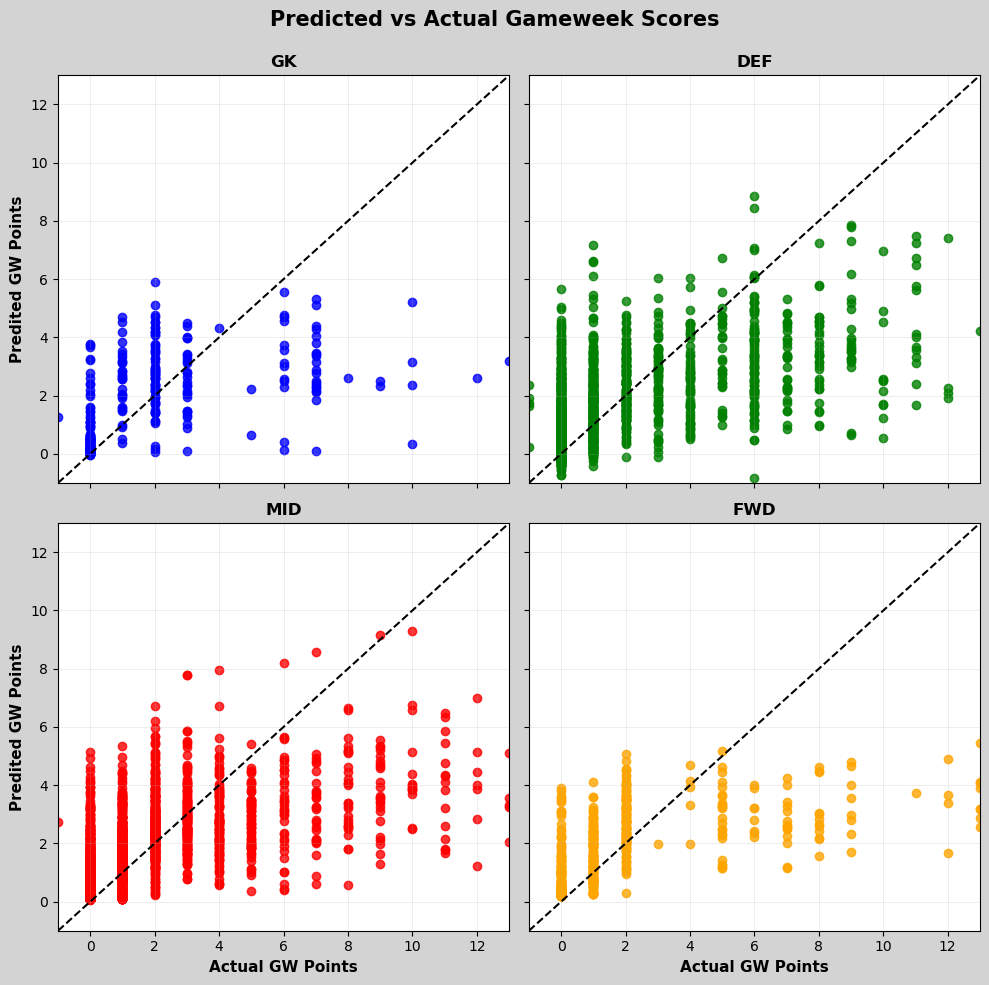

In [46]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)
colours = ('blue', 'green', 'red', 'orange')
vals = np.arange(-1, 22, 1)

for i in range(len(positions)):
    pos = positions[i]
    data = test_sets[pos]
    axes = axs.flat[i]
    axes.scatter(data['Actual'], data['Predicted'], marker='o', color=colours[i], alpha=0.8)
    axes.plot(vals, vals, linestyle='--', color='black')
    axes.set_xlabel('Actual GW Points', fontsize=11, fontweight='bold')
    axes.set_ylabel('Predited GW Points', fontsize=11, fontweight='bold')
    axes.set_title(pos, fontsize=12, fontweight='bold')
    axes.label_outer()
    axes.set_xlim(-1, 13)
    axes.set_ylim(-1, 13)
    axes.set_xticks(np.arange(0, 13, 2))
    axes.set_yticks(np.arange(0, 13, 2))
    axes.grid(True, alpha=0.3, linewidth=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle('Predicted vs Actual Gameweek Scores', fontsize='15', fontweight='bold')
fig.set_facecolor('lightgray')

plt.savefig('fpl1')

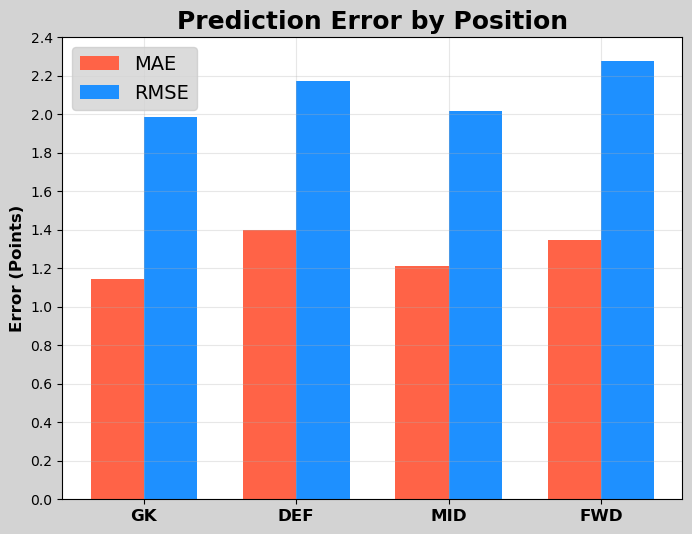

In [51]:
x = np.arange(len(positions))
width = 0.35

fig = plt.figure(figsize=(8, 6))

plt.bar(x-width/2, results_xgb['MAE'], width, label='MAE', color='tomato')
plt.bar(x+width/2, results_xgb['RMSE'], width, label='RMSE', color='dodgerblue')

plt.xticks(x, positions, fontsize=12, fontweight='bold')
plt.yticks(np.arange(0, 2.6, 0.2))
plt.ylabel('Error (Points)', fontsize=12, fontweight='bold')
plt.title('Prediction Error by Position', fontsize=18, fontweight='bold')
plt.grid(True, alpha=0.3)
fig.set_facecolor('lightgray')

plt.legend(fontsize=14, facecolor='lightgray')

plt.savefig('fpl2')

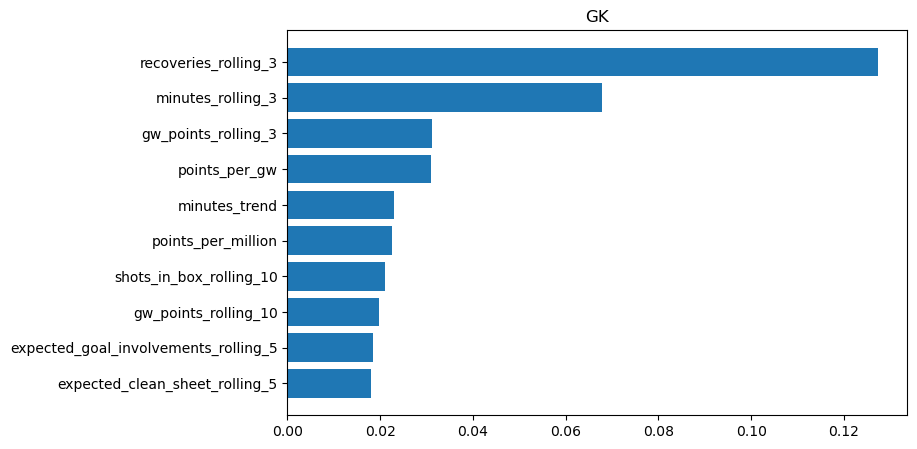

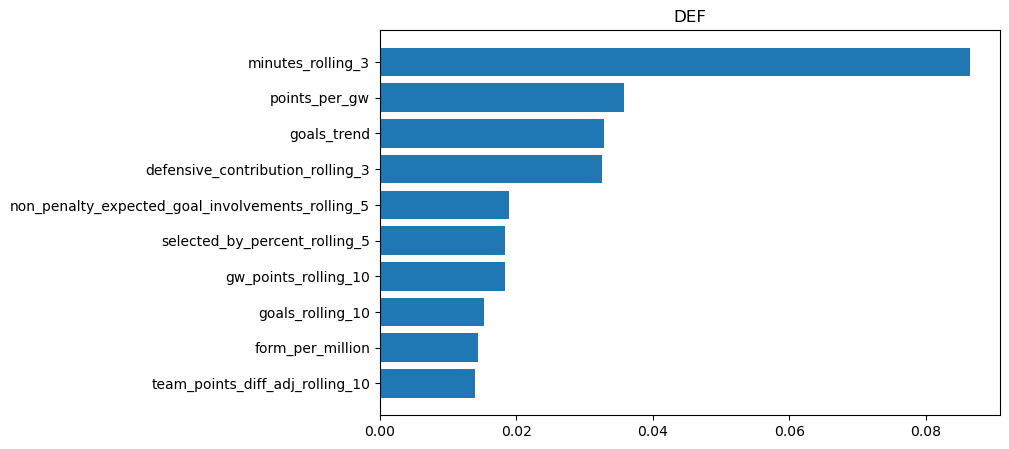

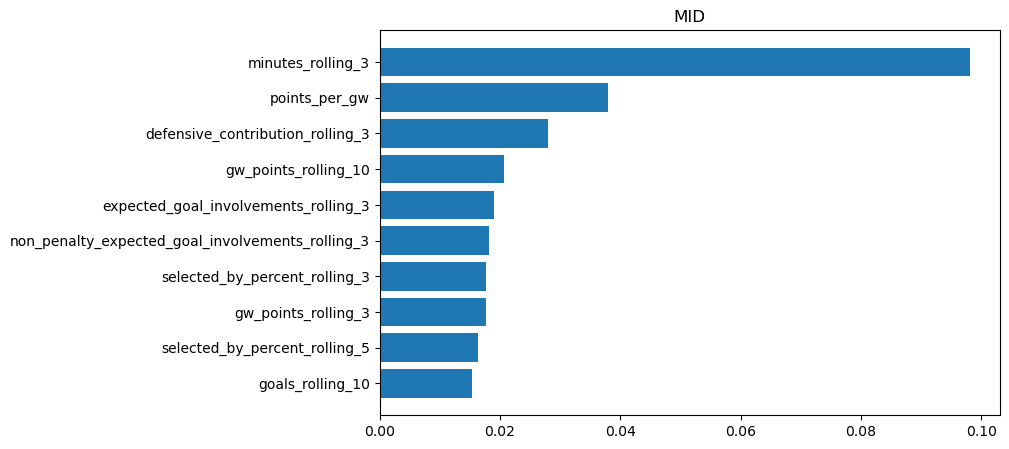

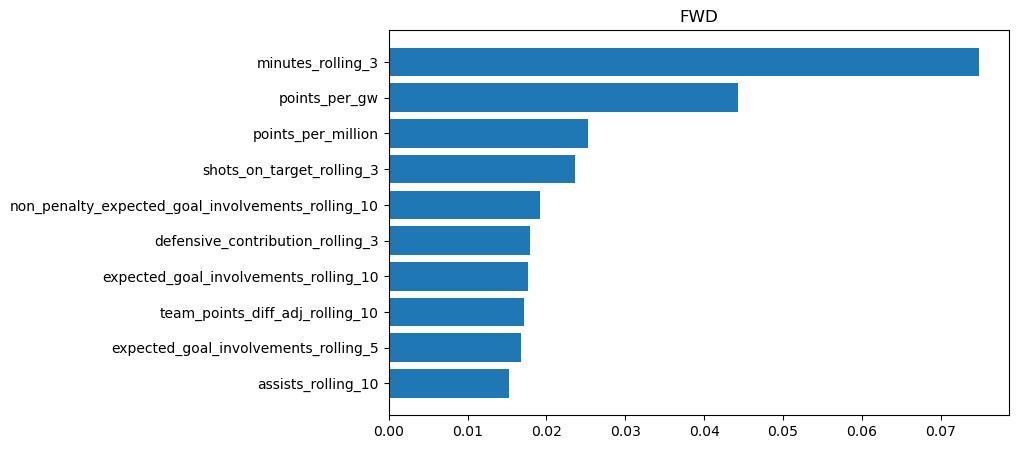

In [45]:
feature_importance = {}

for pos in positions:
    importance = models[pos].named_steps['model'].feature_importances_
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    })
    feature_importance[pos] = importance_df.sort_values('Importance', ascending=False)

    df = feature_importance[pos].head(10)
    plt.figure(figsize=(8, 5))
    plt.barh(df['Feature'], df['Importance'])
    plt.gca().invert_yaxis()
    plt.title(pos)